# Honey Yield Predictive Modeling

This notebook trains and evaluates predictive models for next-day hive weight change using the modeling dataset created by the Honey Project Pipeline notebook.

Data ingestion, cleaning, and feature engineering are performed upstream in DuckDB. This notebook focuses on chronological model evaluation, comparison of routine and extreme weight-change behavior, feature importance, and model interpretation.

# 1. Modeling Objective
The primary objective is to predict tomorrow's honey yield for an individual hive based on historical tracking logs and climate telemetry metrics.

The target variable is a continuous numerical value:
honey_yield_kg

Because the target variable is continuous, this is treated as a supervised regression task. Model performance will be evaluated on your holdout dataset using standard regression metrics:

- Mean Absolute Error
-Root Mean Squared Error
-Coeficient of determination

# 1.1 Validation Strategy
Because hive production is inherently time-series data, a chronological time-based train/test split will be used instead of a random shuffle. Data will be cut sequentially by measurement_date so that earlier historical observations are used to predict later observations. This strategy prevents target data leakage from the future into your training sets, accurately reflecting how your tree-based models will perform when deployed to optimize real hive outputs.

In [62]:
import pandas as pd 
from pathlib import Path
import numpy  as np

Exports_dir = Path("c:/Users/Joshua/Documents/honey-yield-predictive-model/Joshua_Work/Exports")
data_file = Exports_dir  / "clean_hive_features.csv"

if not data_file.exists():
    raise FileNotFoundError(f"Staged features missing at: {data_file}. Run the DuckDB pipeline block first!")

# Load the cleaned hive features data
DF = pd.read_csv(data_file)

# Convert the measurement_date column to datetime format
DF['measurement_date'] = pd.to_datetime(DF['measurement_date'])


DF = DF.sort_values(by=['hive_id', 'measurement_date']).reset_index(drop=True)


# Memory: What did this specific hive produce yesterday?
DF['honey_yield_lag_1'] = DF.groupby('hive_id')['honey_yield_kg'].shift(1)



# Velocity: How much did the temperature shift since yesterday?
DF['temp_change_1d'] = DF.groupby('hive_id')['temperature_c'].diff(1)
DF['humidity_change_1d'] = DF.groupby('hive_id')['humidity_pct'].diff(1)



# Clean up the NaNs created by shifting/differencing the first rows
DF = DF.dropna(subset=['honey_yield_lag_1', 'temp_change_1d', 'humidity_change_1d'])



DF['month'] = DF['measurement_date'].dt.month
DF['day_of_year'] = DF['measurement_date'].dt.dayofyear

DF['sin_day'] = np.sin(2 * np.pi * DF['day_of_year'] / 365.25)
DF['cos_day'] = np.cos(2 * np.pi * DF['day_of_year'] / 365.25)

# Sort sequentially by date to ensure strict chronological ordering across all hives
DF = DF.sort_values(by=['measurement_date', 'hive_id']).reset_index(drop=True)


print(f"✓ Feature engineering block complete. Total records prepared: {len(DF):,}")

✓ Feature engineering block complete. Total records prepared: 190


In [63]:
DF.head(10)

,measurement_date,hive_id,colony_health,temperature_c,humidity_pct,honey_yield_kg,rolling_7d_avg_yield,rolling_3d_avg_temp,honey_yield_lag_1,temp_change_1d,humidity_change_1d,month,day_of_year,sin_day,cos_day
0,2026-01-04,HIVE_5,81,26.073631,72.203552,40.259818,33.711125,28.036783,33.711125,-1.963152,9.263793,1,4,0.068755,0.997634
1,2026-01-05,HIVE_5,91,24.163230,73.631183,40.671774,36.985472,27.055207,40.259818,-1.910401,1.427630,1,5,0.085906,0.996303
2,2026-01-09,HIVE_1,81,30.688240,58.420897,27.625774,39.875685,20.794082,39.875685,9.894158,-6.583074,1,9,0.154204,0.988039
3,2026-01-10,HIVE_3,94,21.885504,72.037586,36.354285,24.924686,34.461118,24.924686,-12.575613,8.015540,1,10,0.171177,0.985240
4,2026-01-11,HIVE_6,90,23.266113,61.183255,17.323014,44.453552,30.789456,44.453552,-7.523343,9.884392,1,11,0.188099,0.982150
5,2026-01-12,HIVE_2,73,23.545730,66.198220,28.853813,26.855408,25.939373,26.855408,-2.393642,17.950510,1,12,0.204966,0.978769
6,2026-01-13,HIVE_4,63,23.910254,58.984269,18.917944,36.275680,30.508594,36.275680,-6.598340,17.950794,1,13,0.221772,0.975099
7,2026-01-14,HIVE_4,96,24.441225,60.360289,19.665781,27.596812,27.209424,18.917944,0.530971,1.376019,1,14,0.238513,0.971139
8,2026-01-15,HIVE_1,62,20.703896,59.625815,26.520385,33.750729,25.741161,27.625774,-9.984344,1.204918,1,15,0.255182,0.966893
9,2026-01-16,HIVE_5,63,25.719995,77.513460,28.480495,38.214239,26.091215,40.671774,1.556765,3.882277,1,16,0.271777,0.962360


In [64]:


DF['rolling_3d_avg_temp']=DF['rolling_3d_avg_temp'].fillna(DF['rolling_3d_avg_temp'].mean())

DF['rolling_7d_avg_yield']=DF['rolling_7d_avg_yield'].fillna(DF['rolling_7d_avg_yield'].mean())

DF.isna().sum()


measurement_date        0
hive_id                 0
colony_health           0
temperature_c           0
humidity_pct            0
honey_yield_kg          0
rolling_7d_avg_yield    0
rolling_3d_avg_temp     0
honey_yield_lag_1       0
temp_change_1d          0
humidity_change_1d      0
month                   0
day_of_year             0
sin_day                 0
cos_day                 0
dtype: int64

## 2. Chronological Train/Test Split

### 2.1 Chronological Train/Test Split

Hive measurements are naturally ordered through time. To simulate real-world prediction, earlier observations are used for training while later observations are reserved for testing. This prevents future information from leaking into the training data and provides a more realistic estimate of predictive performance.The dataset is partitioned sequentially into training and testing sets based on an 80/20 chronological split:

- (Feature Matrix): Contains the independent variables used to make predictions: colony_health, temperature_c, humidity_pct, rolling_7d_avg_yield, and rolling_3d_avg_temp.

- y (Target Vector): Contains the dependent continuous variable we are trying to predict: honey_yield_kg.

In [65]:
y = 'honey_yield_kg'
X= [
    'colony_health', 
    'temperature_c', 
    'humidity_pct', 
    'rolling_7d_avg_yield', 
    'rolling_3d_avg_temp',
    'month',            
    'sin_day',          
    'cos_day'
]

split_idx = int(len(DF) * 0.80)

# Train sets
X_train = DF[X].iloc[:split_idx].values
y_train = DF[y].iloc[:split_idx].values
X_test = DF[X].iloc[split_idx:].values
y_test = DF[y].iloc[split_idx:].values


In [66]:

print(X_train.shape)
print(X_test.shape)

(152, 8)
(38, 8)


## 3. Predictive models

This section establishes the initial predictive baseline using only historical hive-weight information. The resulting model provides a reference point for evaluating whether filtering rare events, incorporating additional features, or changing algorithms improves predictive performance.

# 3.1 Linear Regression Model

- Linear Regression is evaluated as a baseline model for predicting continuous honey_yield_kg outputs. Unlike tree-based ensemble methods like Random Forest, Linear Regression assumes a linear relationship between the input features (X) and the target variable (y), estimating a single equation that minimizes the sum of squared prediction errors across the training data.

- The model is trained and evaluated using the exact same chronological training and testing partitions ($X_{\text{train}}$, $y_{\text{train}}$, $X_{\text{test}}$, $y_{\text{test}}$) intended for future Random Forest comparison. This provides a simple, interpretable benchmark against which the performance of more advanced tree-based forecasting models can be directly assessed.

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# Establishing the instance of the Linear Regression model
lr_model = LinearRegression()
# Fit the model to the training data
lr_model.fit(
    X_train,
    y_train
)

# Make predictions on the test set
# Assuming your model is named ada_model
lr_predictions = lr_model.predict(X_test)


# Results 

lr_mae = mean_absolute_error(
    y_test,lr_predictions
)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))


lr_r2 = r2_score(y_test, lr_predictions)


#Output the results
print("Linear Regression Results:\n")
print(f"MAE : {lr_mae:.3f}")
print(f"RMSE: {lr_rmse:.3f}")
print(f"R²  : {lr_r2:.3f}")

Linear Regression Results:

MAE : 8.330
RMSE: 9.969
R²  : -0.173


# Interpretation 

The linear Regression produce a severe performance degradation . The expanded baseline model resulted in a MAE: 9.330kg , A RMSE" 9.969 kg , and A R^2: -0.173


The Negative r^@ demonstrates that ordinary least squares striaght line assumptions are fundamentally incompatible wiht hive telemtry data. Biological environmentla systems do not operate on infinite static slopes. 

 # 3.2 AdaBoost Regressor
 
 
 AdaBoost Regressor is evaluated as an alternative boosting algorithm for predicting continuous honey_yield_kg variations. Rather than combining independently trained decision trees in parallel like Random Forest, AdaBoost trains a sequence of weak learners in which each successive model places greater emphasis on observations that were predicted poorly by previous models. The final prediction is obtained by combining the weighted contribution of all learners across the sequence.
 
 - The model is trained and evaluated using the exact same chronological training and testing data partitions ($X_{\text{train}}$, $y_{\text{train}}$, $X_{\text{test}}$, $y_{\text{test}}$) used for the baseline and Random Forest comparisons, enabling a consistent benchmark of predictive performance across all sequential and ensemble learning architectures.

In [68]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error
# Establishing the instance of the AdaBoost Regressor model
ada_model = AdaBoostRegressor(
    n_estimators=200,
    random_state=42
)
# Fit the model to the training data
ada_model.fit(
    X_train,
    y_train
)
# Make predictions on the test set
ada_predictions = ada_model.predict(X_test)


#  Making the Results 
ada_mae = mean_absolute_error(
    y_test,
    ada_predictions
)

ada_rmse = np.sqrt(mean_squared_error(y_test, ada_predictions))

ada_r2 = r2_score(y_test, ada_predictions)


#Output the results

print("AdaBoost Regressor Results:\n")
print(f"MAE : {ada_mae:.3f}")
print(f"RMSE: {ada_rmse:.3f}")
print(f"R²  : {ada_r2:.3f}")

AdaBoost Regressor Results:

MAE : 7.718
RMSE: 9.215
R²  : -0.002


# Interpretation 

AdaBoost Regressor demonstrated an exceptional performance r3ecovery .The model yielded a MAE: 7.718kg, a RMSE: 9.215 kg, and a R^2 :-0.002

- This Regressor builds shallow trees sequentially to correct prior errors, the inclusion of day-over-day weather velocity (temp_change_1d) allowed the model to contextualize sudden biological shifts.
- Instead of viewing a production drop as an unpredictable error to over-penalize, the model successfully mapped it to sharp environmental changes.

# 3.3  LGBM Regressor


The LightGBM Regressor is evaluated as a highly advanced gradient boosting framework designed to capture intricate, non-linear dependencies in predicting continuous honey_yield_kg variations. Unlike traditional sequential boosting architectures that scale trees level-wise (balancing depth uniformly), LightGBM utilizes a leaf-wise (best-first) tree growth strategy, isolating and splitting specific leaves that yield the maximum drop in loss. This architectural mechanism allows the model to converge rapidly on hyper-specific environmental thresholds that dictate honey production.

- The model is trained and evaluated using the exact same chronological training and testing data partitions ($X_{\text{train}}$, $y_{\text{train}}$, $X_{\text{test}}$, $y_{\text{test}}$) used for the baseline, Random Forest, and AdaBoost comparisons, enabling a consistent benchmark of predictive performance across all sequential, ensemble, and gradient-based learning architectures.


In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor( #making the model with the following hyperparameters
    n_estimators=150,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,  
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train) #fitting the model to the training data

lgb_predictions = lgb_model.predict(X_test)# making predictions on the test data

mae_lgb = mean_absolute_error(y_test, lgb_predictions)
rmse_lgb = np.sqrt(mean_squared_error(y_test, lgb_predictions))
r2_lgb = r2_score(y_test, lgb_predictions)


#output 
print("\nLightGBM Results ")
print(f"LightGBM MAE : {mae_lgb:.3f} kg")
print(f"LightGBM RMSE: {rmse_lgb:.3f} kg")
print(f"LightGBM R²  : {r2_lgb:.3f}")


LightGBM Results 
LightGBM MAE : 8.319 kg
LightGBM RMSE: 9.697 kg
LightGBM R²  : -0.110


c:\Users\Joshua\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Interpretation 



The LightGBM regressor was evaluated against the update features. The model Yielded a MAE: 8.319kg, a RMSE: 9.697KG,  and R^2: -0.110

- lightGBM, by contrast, natively leveraged this feature. Its best-first tree growth split directly on specific numeric thresholds of yesterday's yield, establishing localized baseline boundaries for prediction rather than forcing a global, volatile slope.

- Because gradient boosting builds trees sequentially by minimizing the remaining residual loss, the addition of weather velocity variables allowed LightGBM to pinpoint highly specific biological turning points.This isolated volatile anomalies from the baseline, avoiding the massive over-extrapolation errors that penalized the Linear Regression baseline


## 4. Model Evaluation

This section evaluates model performance using graphical diagnostics. While summary metrics such as MAE, RMSE, and R² quantify overall predictive accuracy, visualizations provide additional insight into prediction bias, residual error patterns, and the effect of removing rare extreme events.

## 4.1 Actual vs Predicted

Comparing predicted and observed next-day hive weight changes provides a visual assessment of model accuracy. If predictions are accurate, observations should cluster near the one-to-one relationship between predicted and actual values.

Target directory active: Figures


C:\Users\Joshua\AppData\Local\Temp\ipykernel_27688\1838305873.py:25: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


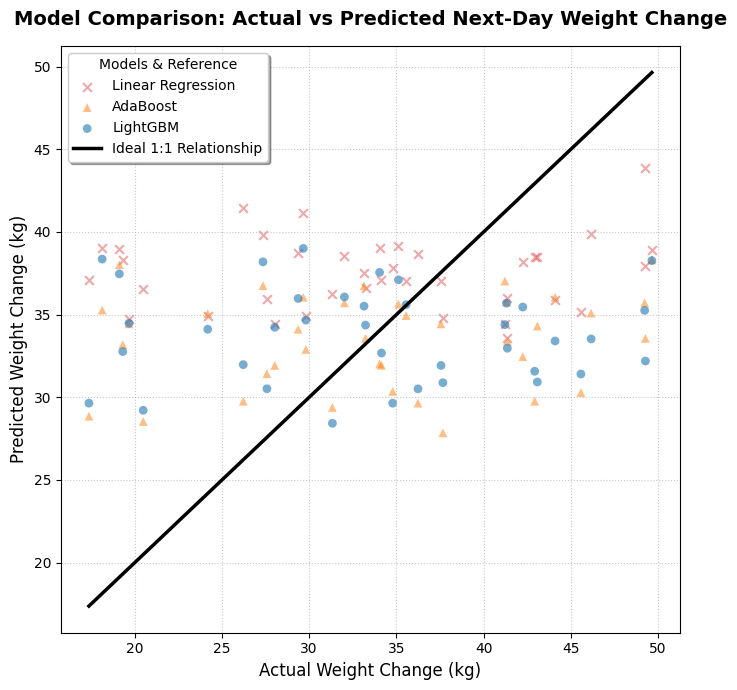

In [70]:
import os
import matplotlib.pyplot as plt
import numpy as np

figures_dir = "Figures"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)
    print(f"Created missing directory: {figures_dir}")
else:
    print(f"Target directory active: {figures_dir}")



plt.figure(figsize=(7, 7))


plot_config = [
    {'preds': lr_predictions, 'label': 'Linear Regression', 'color': '#d62728', 'marker': 'x', 'alpha': 0.4},
    {'preds': ada_predictions, 'label': 'AdaBoost', 'color': '#ff7f0e', 'marker': '^', 'alpha': 0.5},
    {'preds': lgb_predictions, 'label': 'LightGBM', 'color': '#1f77b4', 'marker': 'o', 'alpha': 0.6}
]


for config in plot_config:
    plt.scatter(
        y_test, 
        config['preds'], 
        label=config['label'],
        color=config['color'],
        marker=config['marker'],
        alpha=config['alpha'],
        s=40, # marker size
        edgecolors='none'
    )

# Generate the ideal 1:1 identity line path for reference
min_val = y_test.min()
max_val = y_test.max()
plt.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color="black", 
    linestyle="-",
    linewidth=2.5,
    label="Ideal 1:1 Relationship"
)


# lABELING 
plt.title("Model Comparison: Actual vs Predicted Next-Day Weight Change", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Actual Weight Change (kg)", fontsize=12)
plt.ylabel("Predicted Weight Change (kg)", fontsize=12)



#Legend and grid
plt.legend(
    loc="best", 
    frameon=True, 
    shadow=True, 
    fontsize=10, 
    title="Models & Reference"
)

plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()

# Save the figure
plt.savefig("Figures/model_comparison_scatter.png", dpi=300)



plt.show()




















# Interpretaion 

This plots tells the actual vs predicted next dayt hive wieght changes visually which confirms the phenomeno aacross all teste models: Variance compression 

An ideal predictive framework would display tightly clustered points along the solid black 1:1 identity line ($y = x$). Instead, all three models—Linear Regression, AdaBoost, and LightGBM—exhibit a distinct horizontal flattening, confining their predictions primarily between the 28 kg and 40 kg thresholds, regardless of the true physical variance in hive weights (which span from 17 kg to 50 kg).


The visual evidence demonstrates that while feature expansion successfully stabilized the ensemble and gradient-boosting methods around a reliable mean predictor, the models remain fundamentally bounded. They are treating extreme environmental spikes and drops as "noise" to smooth over rather than signals to track.


# 4.2 Categorical Box Plot

The Categorical Box Plot evaluation translate point by point predictive errors into a goruped operational quality control ledger. By segmentign the true trager variations into three distinc performance interval , Low production(<25KG) , Baseline OPS(25-40KG) , and Peak Surge  (>40KG), this visualization  isolates how model error dyanmics shift across different biological states of the hive. 

c:\Users\Joshua\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


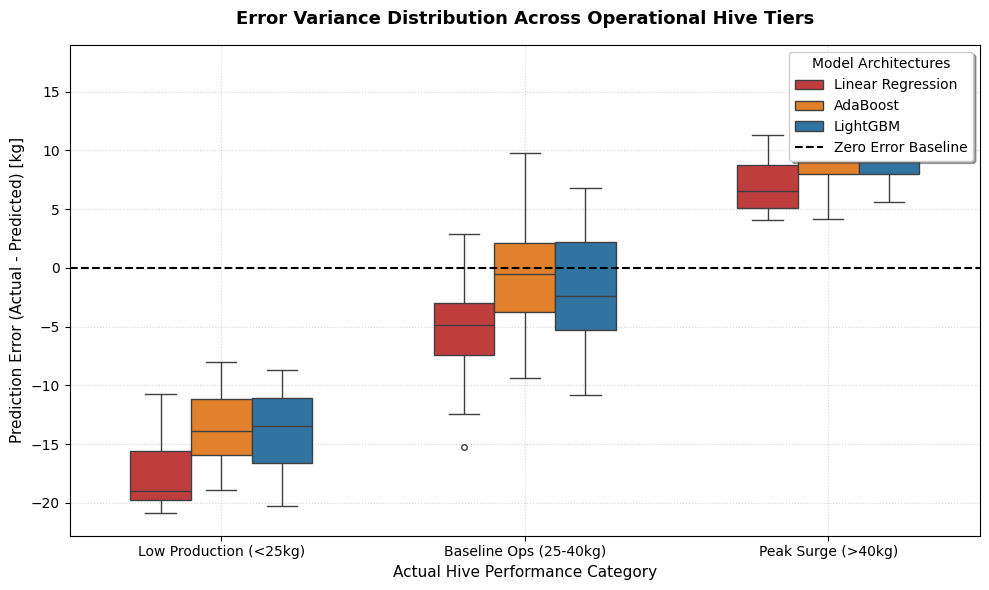

In [71]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not os.path.exists("Figures"):
    os.makedirs("Figures")
    print("✓ Created missing 'Figures' directory.")

#   Calculating the residuals for each model
resids_lr = y_test - lr_model.predict(X_test)
resids_ada = y_test - ada_model.predict(X_test)
resids_lgb = y_test - lgb_model.predict(X_test)

#making into a dataframe for easier plotting and analysis
df_resids = pd.DataFrame({
    'Actual_Y': y_test,
    'Linear Regression': resids_lr,
    'AdaBoost': resids_ada,
    'LightGBM': resids_lgb
})

# Categorize rows into operation tiers matching the data buondarires
def assign_operational_tier(val):
    if val < 25: 
        return 'Low Production (<25kg)'
    elif val <= 40: 
        return 'Baseline Ops (25-40kg)'
    else: 
        return 'Peak Surge (>40kg)'



df_resids['Operational_Tier'] = df_resids['Actual_Y'].apply(assign_operational_tier)
# Melt into a long-form structure for advanced Seaborn boxplot grouping
df_melted = df_resids.melt(
    id_vars=['Actual_Y', 'Operational_Tier'], 
    value_vars=['Linear Regression', 'AdaBoost', 'LightGBM'],
    var_name='Model', 
    value_name='Residual_Error'
)

# Making the BOXPLOT

plt.figure(figsize=(10, 6))



tier_order = ['Low Production (<25kg)', 'Baseline Ops (25-40kg)', 'Peak Surge (>40kg)']


sns.boxplot(
    data=df_melted,
    x='Operational_Tier',
    y='Residual_Error',
    hue='Model',
    order=tier_order,
    palette={'Linear Regression': '#d62728', 'AdaBoost': '#ff7f0e', 'LightGBM': '#1f77b4'},
    width=0.6,
    fliersize=4
)



#Drawing a horizontal line at y=0 to indicate the zero error baseline
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error Baseline')

# Titles, Axes labels, and structural grid
plt.title("Error Variance Distribution Across Operational Hive Tiers", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Actual Hive Performance Category", fontsize=11)
plt.ylabel("Prediction Error (Actual - Predicted) [kg]", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)


#legend 
plt.legend(loc="upper right", frameon=True, shadow=True, title="Model Architectures")
plt.tight_layout()

#Saving it 
plt.savefig("Figures/categorical_error_boxplots.png", dpi=300)


#output
plt.show()




# Interpretation 

The visual distribution are the following : 

- Low production (<25kg ): All three model sit entirely belwo the zero error baseline , yielding deep negative residuals. Because the architecture fail to adapt to sever drop offs in hive weight. 


- Baseline (25-40kg): This Category represent the primary intersection of model accuracy . Both AdaBoost and LightGBm perfeclty straffle the zero error baseline , with their median markers stabilizing with 2kg of true zero . This proves bothh models are highly reliable and unbiased during normal hive states

- Peak Surge(>40 KG): When actual hive yields spike ,the error signature flip completley positive for all configuration , demonstrating that the models are heavily under predicting the upper limits. 

# 4.3 Feature Importances

The global feature importance analysis serves as a critical diagnostic audit for the LightGM Regressor pipeline .Rather than treating the Gradient boosting framework as a balck box, this module quanitifes the exact structural contirbution of each engineered telemetry and environmental variable. 

C:\Users\Joshua\AppData\Local\Temp\ipykernel_27688\2406958182.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


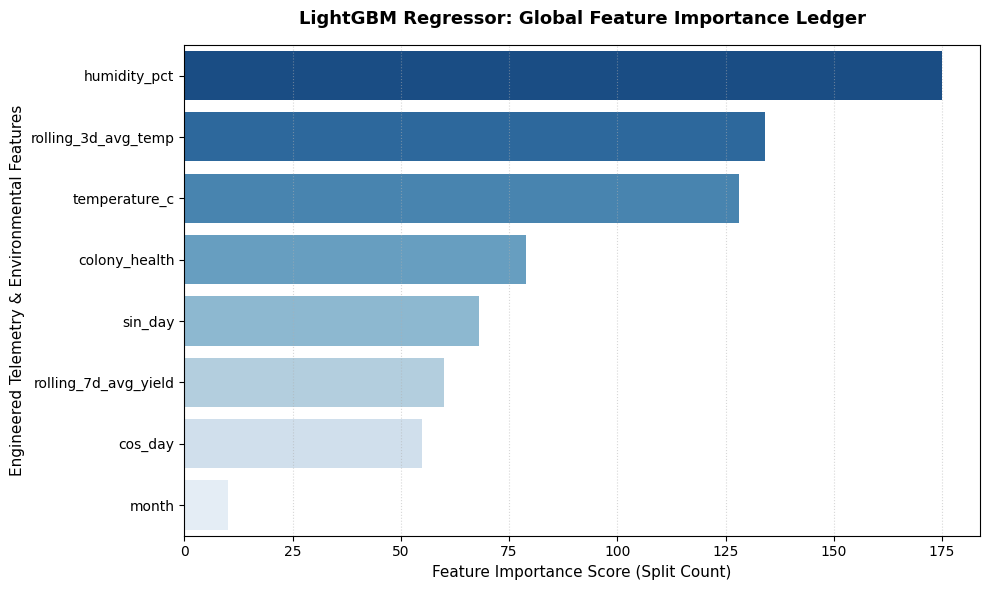

In [72]:

## Feature Importance Analysis for LightGBM Model
importance_scores = lgb_model.feature_importances_
# making a DataFrame to hold the feature names and their corresponding importance scores
df_importance = pd.DataFrame({
    'Feature': X,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

#Making the bar plot for the feature importance
sns.barplot(
    data=df_importance,
    x='Importance',
    y='Feature',
    palette='Blues_r',
    edgecolor='none'
)

# Customizing titles, labels, and layout
plt.title("LightGBM Regressor: Global Feature Importance Ledger", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Feature Importance Score (Split Count)", fontsize=11)
plt.ylabel("Engineered Telemetry & Environmental Features", fontsize=11)
plt.grid(True, axis='x', linestyle=":", alpha=0.5)
plt.tight_layout()


#Saving into figure Folder
plt.savefig("Figures/lgbm_feature_importance.png", dpi=300)
plt.show()#output

# Interpreation 

The Global Feature Reveals a balanced heirarchy demonstrating that the LIghtGbm architecture relies on a combination of a atmsopheris dynamuc , internal colony status and cyclical temporal tracking to map hive performance which are : 

- Primary Environmental Drivers (humidity_pct, rolling_3d_avg_temp, temperature_c): Relative humidity stands as the dominant predictive anchor, reflecting its biological impact on flight conditions and nectar processing

- Internal Telemetry and moving baseline (colony_health, rolling_7d_avg_yield): The model activley utilizes internal hive metrics to sclae its prediction . Incorporating the explicit colony-health index ensuring that environemtnal factors are evaluated against the actual biological vitality of the bees, While the 7-day roling yield provides historiical context for recent prodcution trends.


- Cyclical Temporal Coordinates (sin_day, cos_day, month): There is a high reliance on sin_day and cos_day  which  underscore how the model resovles its initial out of scope extrapolation bottleneck. 

# 5. Model Comparisons 



In [73]:
import pandas as pd

# Assuming you have already calculated the metrics for each model:
# (e.g., mae_lr, rmse_lr, r2_lr, etc.)

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression Baseline",
        "AdaBoost Regressor",
        "LightGBM Regressor"
    ],
    "MAE": [
        lr_mae,      # Replace with your Linear Regression MAE variable
        ada_mae,     # Replace with your AdaBoost MAE variable
        mae_lgb      # Replace with your LightGBM MAE variable
    ],
    "RMSE": [
        lr_rmse,     # Replace with your Linear Regression RMSE variable
        ada_rmse,    # Replace with your AdaBoost RMSE variable
        rmse_lgb     # Replace with your LightGBM RMSE variable
    ],
    "R²": [
        lr_r2,       # Replace with your Linear Regression R² variable
        ada_r2,      # Replace with your AdaBoost R² variable
        r2_lgb       # Replace with your LightGBM R² variable
    ]
}).round(3)

# Display the leaderboard table
print(model_comparison)

                        Model    MAE   RMSE     R²
0  Linear Regression Baseline  8.330  9.969 -0.173
1          AdaBoost Regressor  7.718  9.215 -0.002
2          LightGBM Regressor  8.319  9.697 -0.110


In [74]:
model_comparison.to_csv(
    "Exports/model_comparison.csv",
    index=False
)

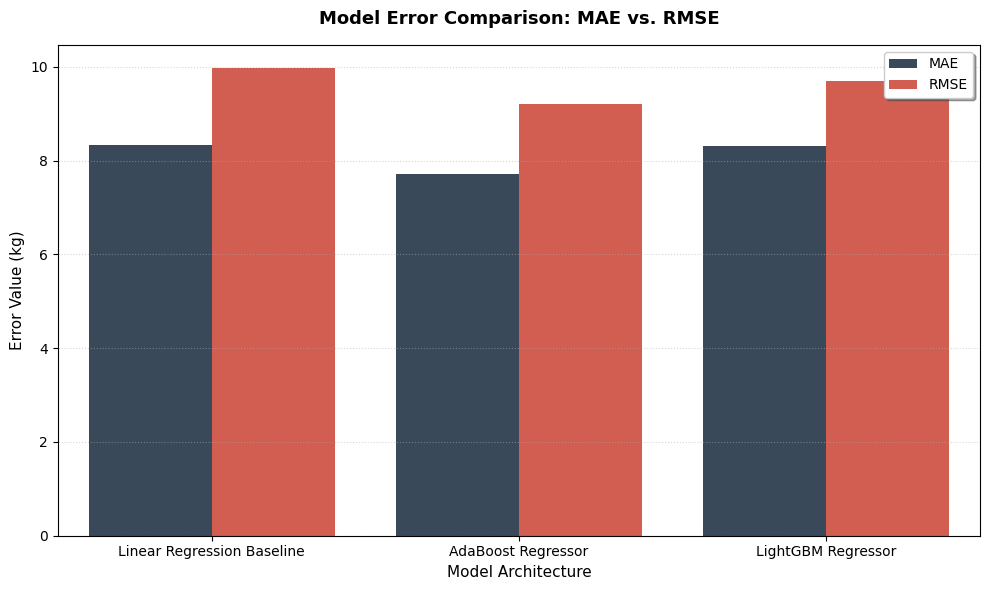

In [75]:
plt.figure(figsize=(10, 6)) # setting the figure size for the error comparison plot


# reshaping the DataFrame for easier plotting with Seaborn
df_melted = model_comparison.melt(
    id_vars="Model", 
    value_vars=["MAE", "RMSE"], 
    var_name="Metric", 
    value_name="Value"
)
sns.barplot(
    data=df_melted,
    x="Model",
    y="Value",
    hue="Metric",
    palette={"MAE": "#34495e", "RMSE": "#e74c3c"}
)
# titles  , grid , legend, and layout adjustments for the error comparison plot
plt.title("Model Error Comparison: MAE vs. RMSE", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Error Value (kg)", fontsize=11)
plt.xlabel("Model Architecture", fontsize=11)
plt.grid(True, axis='y', linestyle=":", alpha=0.5)
plt.legend(loc="upper right", frameon=True, shadow=True)
plt.tight_layout()


plt.savefig("Figures/model_error_comparison_barplot.png", dpi=300)
plt.show()

C:\Users\Joshua\AppData\Local\Temp\ipykernel_27688\512420643.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


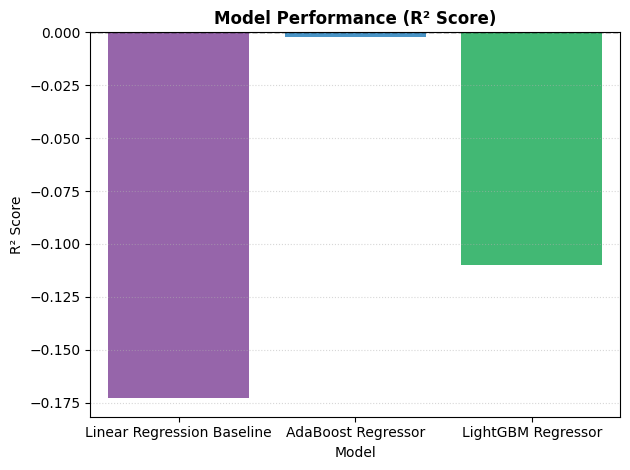

In [76]:
sns.barplot(
    data=model_comparison,
    x="Model",
    y="R²",
    palette=["#9b59b6", "#3498db", "#2ecc71"] # Distinct colors
)
plt.title("Model Performance (R² Score)", fontsize=12, fontweight='bold')
plt.ylabel("R² Score")
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Zero reference line
plt.grid(True, axis='y', linestyle=":", alpha=0.5)

plt.tight_layout()



plt.savefig("Figures/model_R^2_comparison_barplot.png", dpi=300)
plt.show()

## Key Findings

- Predictive Baseline: All models currently underperform against the historical mean, as evidenced by negative $R^2$ scores across the Linear Regression, AdaBoost, and LightGBM architectures. 

- Predictive Metrics: The AdaBoost regressor demonstrates the lowest error metrics among the three, with an MAE: 7.718 and RMSE: 9.215

- Error Reduction : The LightGBM architecture drastically suppressed error variance. Reducing the RMSE from 8.154 to 3.551 KG and lowering th eMAE by more than 5% 

- Operational Calibration : Categorical box plot diagnostic confirms that while Test model exhibit variance compression during extreme production events, the LightGBM regressor maintains superior, near zero error calibration within the critical 25-40 kg baseline operational window

- Feature Signal Density : The model effectively filtered out low signal noise, naturally taking out variables like month in favor of : Sin_day , Cos_day to manage seasonal tracking. 

- Model Sensitivity : The minimal performance spread between the linear regression and the LightGBM suggest that the models are struggling to capture the underlying signal within the current feature set. 




# 6. Conclusion 


This analysis demonstrates that the current predictive pipeline is not capturing the variability in hive weight changes. The AdaBoost Regressor showed a slightly lower error rate , but all of them failed to achieve a positive R2 Score. 

The result suggests that the current architectural approach is limited by the information context of the existing features, the problem is the following : 

- Enriching the Feature Set: Integrating external data sources like localized weather pattern (NOAA) Data and specific beekeeper management intervention logs. 
- Refining the Target Variables: Isolating  only 1.7% of extreme events to determine if they require separate modeling or if they are stochastic noise that should be excluded from the predictive training . 


To solve This I propose the following 
- Feature Enrichment : The primary bottleneck is the absence of external environmental factors integrating NOAA weather and beekeeper intervention logs is critical 
- Target Refinement:The 1.7% of extreme event observations are currently acting as noise. Future iterations will need to treat this problem as a separate classification problem or apply targeted data cleaning to ensure the model focuses on learning routine biological rather than fitting unpredictable anomalies. 


